In [2]:
import bagpy
from bagpy import bagreader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

In [67]:
file_dsr = '/home/henrypcl/rosbag/dsr_v08_085_03_good.bag'
file_pds = '/home/henrypcl/rosbag/2024-01-26-16-46-33.bag'
readbag_dsr = bagreader(file_dsr)
readbag_pds = bagreader(file_pds)

print(readbag_dsr.topic_table)

[INFO]  Data folder /home/henrypcl/rosbag/dsr_v08_085_03_good already exists. Not creating.
[INFO]  Data folder /home/henrypcl/rosbag/2024-01-26-16-46-33 already exists. Not creating.
                       Topics                       Types  Message Count  \
0   /tbot149/april_data_multi  std_msgs/Float32MultiArray           3684   
1            /tbot149/cmd_vel         geometry_msgs/Twist           1844   
2               /tbot149/data         geometry_msgs/Twist           1844   
3             /tbot149/l_traj  std_msgs/Float32MultiArray           1844   
4               /tbot149/odom           nav_msgs/Odometry           3015   
5           /tbot149/tag_data  std_msgs/Float32MultiArray           1844   
6             /tbot149/target         geometry_msgs/Point           1844   
7   /tbot162/april_data_multi  std_msgs/Float32MultiArray           3684   
8            /tbot162/cmd_vel         geometry_msgs/Twist           1844   
9               /tbot162/data         geometry_msgs/Twis

### Plot robot trajectory

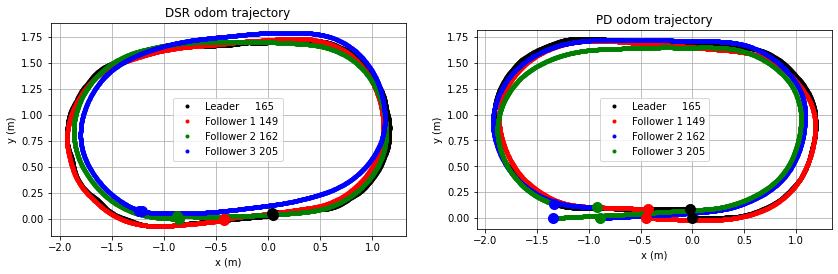

In [68]:
odom165_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot165/odom'))
posx165_dsr = odom165_data_dsr['pose.pose.position.x'].to_numpy()
posy165_dsr = odom165_data_dsr['pose.pose.position.y'].to_numpy()
odom165_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot165/odom'))
posx165_pds = odom165_data_pds['pose.pose.position.x'].to_numpy()
posy165_pds = odom165_data_pds['pose.pose.position.y'].to_numpy()

odom149_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot149/odom'))
posx149_dsr = odom149_data_dsr['pose.pose.position.x'].to_numpy()
posy149_dsr = odom149_data_dsr['pose.pose.position.y'].to_numpy()
odom149_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot149/odom'))
posx149_pds = odom149_data_pds['pose.pose.position.x'].to_numpy()
posy149_pds = odom149_data_pds['pose.pose.position.y'].to_numpy()

odom162_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot162/odom'))
posx162_dsr = odom162_data_dsr['pose.pose.position.x'].to_numpy()
posy162_dsr = odom162_data_dsr['pose.pose.position.y'].to_numpy()
odom162_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot162/odom'))
posx162_pds = odom162_data_pds['pose.pose.position.x'].to_numpy()
posy162_pds = odom162_data_pds['pose.pose.position.y'].to_numpy()

odom205_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot205/odom'))
posx205_dsr = odom205_data_dsr['pose.pose.position.x'].to_numpy()
posy205_dsr = odom205_data_dsr['pose.pose.position.y'].to_numpy()
odom205_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot205/odom'))
posx205_pds = odom205_data_pds['pose.pose.position.x'].to_numpy()
posy205_pds = odom205_data_pds['pose.pose.position.y'].to_numpy()

d = 0.45

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,6))
ax1.plot(posx165_dsr,     posy165_dsr,'k.', linewidth=3,label='Leader     165')
ax1.plot(posx149_dsr-d,   posy149_dsr,'r.', linewidth=3,label='Follower 1 149')
ax1.plot(posx162_dsr-2*d, posy162_dsr,'g.', linewidth=3,label='Follower 2 162')
ax1.plot(posx205_dsr-3*d, posy205_dsr,'b.', linewidth=3,label='Follower 3 205')
ax1.plot(posx165_dsr[0],     posy165_dsr[0],'ko', markersize=10)
ax1.plot(posx149_dsr[0]-d,   posy149_dsr[0],'ro', markersize=10)
ax1.plot(posx162_dsr[0]-2*d, posy162_dsr[0],'go', markersize=10)
ax1.plot(posx205_dsr[0]-3*d, posy205_dsr[0],'bo', markersize=10)
ax1.plot(posx165_dsr[-1],     posy165_dsr[-1],'ko', markersize=10)
ax1.plot(posx149_dsr[-1]-d,   posy149_dsr[-1],'ro', markersize=10)
ax1.plot(posx162_dsr[-1]-2*d, posy162_dsr[-1],'go', markersize=10)
ax1.plot(posx205_dsr[-1]-3*d, posy205_dsr[-1],'bo', markersize=10)
ax1.set_xlabel('x (m)')
ax1.set_ylabel('y (m)')
ax1.set_aspect('equal')
ax1.set_title('DSR odom trajectory')
ax1.legend()
ax1.grid()

ax2.plot(posx165_pds,     posy165_pds,'k.', linewidth=3,label='Leader     165')
ax2.plot(posx149_pds-d,   posy149_pds,'r.', linewidth=3,label='Follower 1 149')
ax2.plot(posx162_pds-2*d, posy162_pds,'b.', linewidth=3,label='Follower 2 162')
ax2.plot(posx205_pds-3*d, posy205_pds,'g.', linewidth=3,label='Follower 3 205')
ax2.plot(posx165_pds[0],     posy165_pds[0],'ko', markersize=10)
ax2.plot(posx149_pds[0]-d,   posy149_pds[0],'ro', markersize=10)
ax2.plot(posx162_pds[0]-2*d, posy162_pds[0],'go', markersize=10)
ax2.plot(posx205_pds[0]-3*d, posy205_pds[0],'bo', markersize=10)
ax2.plot(posx165_pds[-1],     posy165_pds[-1],'ko', markersize=10)
ax2.plot(posx149_pds[-1]-d,   posy149_pds[-1],'ro', markersize=10)
ax2.plot(posx162_pds[-1]-2*d, posy162_pds[-1],'go', markersize=10)
ax2.plot(posx205_pds[-1]-3*d, posy205_pds[-1],'bo', markersize=10)
ax2.set_xlabel('x (m)')
ax2.set_ylabel('y (m)')
ax2.set_aspect('equal')
ax2.set_title('PD odom trajectory')
ax2.legend()
ax2.grid()

### Plot spacing error

data149 dsr duration: 122.86438655853271 data length: 1844
data149 pds duration: 130.53207302093506 data length: 1959
data162 dsr duration: 122.7985212802887 data length: 1843
data162 pds duration: 130.536395072937 data length: 1959
data205 dsr duration: 122.86804962158203 data length: 1844
data205 pds duration: 130.53486347198486 data length: 1959


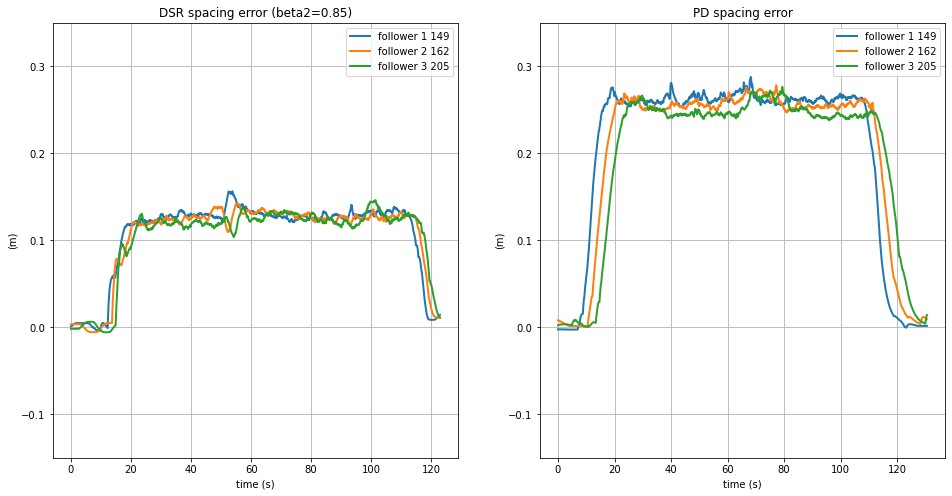

In [69]:
data149_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot149/data'))
data149_t_dsr = data149_data_dsr['Time'].to_numpy()
data149_t_dsr = data149_t_dsr-data149_t_dsr[0]   # plot this
spacing_e149_dsr = data149_data_dsr['linear.x']  # plot this
print('data149 dsr duration:', max(data149_t_dsr)-min(data149_t_dsr), 'data length:', len(data149_t_dsr))
data149_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot149/data'))
data149_t_pds = data149_data_pds['Time'].to_numpy()
data149_t_pds = data149_t_pds-data149_t_pds[0]   # plot this
spacing_e149_pds = data149_data_pds['linear.x']  # plot this
print('data149 pds duration:', max(data149_t_pds)-min(data149_t_pds), 'data length:', len(data149_t_pds))

data162_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot162/data'))
data162_t_dsr = data162_data_dsr['Time'].to_numpy()
data162_t_dsr = data162_t_dsr-data162_t_dsr[0]   # plot this
spacing_e162_dsr = data162_data_dsr['linear.x']  # plot this
print('data162 dsr duration:', max(data162_t_dsr)-min(data162_t_dsr), 'data length:', len(data162_t_dsr))
data162_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot162/data'))
data162_t_pds = data162_data_pds['Time'].to_numpy()
data162_t_pds = data162_t_pds-data162_t_pds[0]   # plot this
spacing_e162_pds = data162_data_pds['linear.x']  # plot this
print('data162 pds duration:', max(data162_t_pds)-min(data162_t_pds), 'data length:', len(data162_t_pds))

data205_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot205/data'))
data205_t_dsr = data205_data_dsr['Time'].to_numpy()
data205_t_dsr = data205_t_dsr-data205_t_dsr[0]   # plot this
spacing_e205_dsr = data205_data_dsr['linear.x']  # plot this
print('data205 dsr duration:', max(data205_t_dsr)-min(data205_t_dsr), 'data length:', len(data205_t_dsr))
data205_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot205/data'))
data205_t_pds = data205_data_pds['Time'].to_numpy()
data205_t_pds = data205_t_pds-data205_t_pds[0]   # plot this
spacing_e205_pds = data205_data_pds['linear.x']  # plot this
print('data205 pds duration:', max(data205_t_pds)-min(data205_t_pds), 'data length:', len(data205_t_pds))

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(16,8))
ax1.plot(data149_t_dsr, spacing_e149_dsr,'-', linewidth=2, label='follower 1 149')
ax1.plot(data162_t_dsr, spacing_e162_dsr,'-', linewidth=2, label='follower 2 162')
ax1.plot(data205_t_dsr, spacing_e205_dsr,'-', linewidth=2, label='follower 3 205')
ax1.set_title('DSR spacing error (beta2=0.85)')
ax1.set_ylim(-0.15, 0.35)
ax1.set_xlabel('time (s)')
ax1.set_ylabel('(m)')
ax1.legend()
ax1.grid()

ax2.plot(data149_t_pds, spacing_e149_pds,'-', linewidth=2, label='follower 1 149')
ax2.plot(data162_t_pds, spacing_e162_pds,'-', linewidth=2, label='follower 2 162')
ax2.plot(data205_t_pds, spacing_e205_pds,'-', linewidth=2, label='follower 3 205')
ax2.set_title('PD spacing error')
ax2.set_ylim(-0.15, 0.35)
ax2.set_xlabel('time (s)')
ax2.set_ylabel('(m)')
ax2.legend()
ax2.grid()

### Odom time stamp check

odom165 dsr duration: 184.39929509162903 data length: 4868
odom165 pds duration: 198.0869448184967 data length: 5176
odom149 dsr duration: 184.4140818119049 data length: 4463
odom149 pds duration: 198.03509163856506 data length: 4858
odom162 dsr duration: 184.40747690200806 data length: 4459
odom149 pds duration: 198.06574273109436 data length: 4866
odom205 dsr duration: 184.4193720817566 data length: 4436
odom205 pds duration: 198.0359320640564 data length: 4757


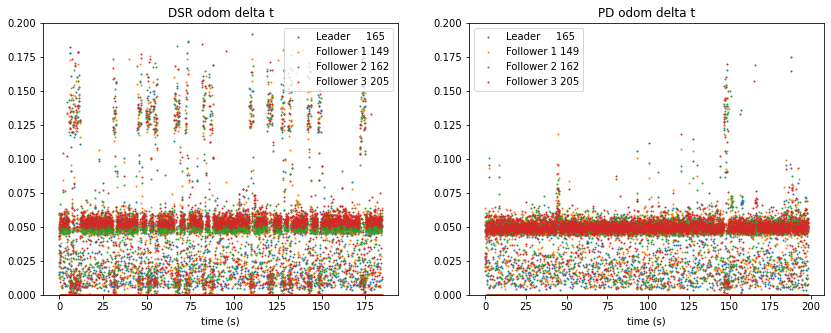

In [10]:
odom165_t_dsr = odom165_data_dsr['Time'].to_numpy()
odom165_t_dsr = odom165_t_dsr-odom165_t_dsr[0]
print('odom165 dsr duration:', max(odom165_t_dsr)-min(odom165_t_dsr), 'data length:', len(odom165_t_dsr))
odom165_t_pds = odom165_data_pds['Time'].to_numpy()
odom165_t_pds = odom165_t_pds-odom165_t_pds[0]
print('odom165 pds duration:', max(odom165_t_pds)-min(odom165_t_pds), 'data length:', len(odom165_t_pds))

odom149_t_dsr = odom149_data_dsr['Time'].to_numpy()
odom149_t_dsr = odom149_t_dsr-odom149_t_dsr[0]
print('odom149 dsr duration:', max(odom149_t_dsr)-min(odom149_t_dsr), 'data length:', len(odom149_t_dsr))
odom149_t_pds = odom149_data_pds['Time'].to_numpy()
odom149_t_pds = odom149_t_pds-odom149_t_pds[0]
print('odom149 pds duration:', max(odom149_t_pds)-min(odom149_t_pds), 'data length:', len(odom149_t_pds))

odom162_t_dsr = odom162_data_dsr['Time'].to_numpy()
odom162_t_dsr = odom162_t_dsr-odom162_t_dsr[0]
print('odom162 dsr duration:', max(odom162_t_dsr)-min(odom162_t_dsr), 'data length:', len(odom162_t_dsr))
odom162_t_pds = odom162_data_pds['Time'].to_numpy()
odom162_t_pds = odom162_t_pds-odom162_t_pds[0]
print('odom149 pds duration:', max(odom162_t_pds)-min(odom162_t_pds), 'data length:', len(odom162_t_pds))

odom205_t_dsr = odom205_data_dsr['Time'].to_numpy()
odom205_t_dsr = odom205_t_dsr-odom205_t_dsr[0]
print('odom205 dsr duration:', max(odom205_t_dsr)-min(odom205_t_dsr), 'data length:', len(odom205_t_dsr))
odom205_t_pds = odom205_data_pds['Time'].to_numpy()
odom205_t_pds = odom205_t_pds-odom205_t_pds[0]
print('odom205 pds duration:', max(odom205_t_pds)-min(odom205_t_pds), 'data length:', len(odom205_t_pds))

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,5))
ax1.plot(odom165_t_dsr[:-1], np.diff(odom165_t_dsr), '.', markersize='2', label='Leader     165')
ax1.plot(odom149_t_dsr[:-1], np.diff(odom149_t_dsr), '.', markersize='2', label='Follower 1 149')
ax1.plot(odom162_t_dsr[:-1], np.diff(odom162_t_dsr), '.', markersize='2', label='Follower 2 162')
ax1.plot(odom205_t_dsr[:-1], np.diff(odom205_t_dsr), '.', markersize='2', label='Follower 3 205')
ax1.set_xlabel('time (s)')
ax1.set_title('DSR odom delta t')
ax1.set_ylim(0.0, 0.2)
ax1.legend()

ax2.plot(odom165_t_pds[:-1], np.diff(odom165_t_pds), '.', markersize='2', label='Leader     165')
ax2.plot(odom149_t_pds[:-1], np.diff(odom149_t_pds), '.', markersize='2', label='Follower 1 149')
ax2.plot(odom162_t_pds[:-1], np.diff(odom162_t_pds), '.', markersize='2', label='Follower 2 162')
ax2.plot(odom205_t_pds[:-1], np.diff(odom205_t_pds), '.', markersize='2', label='Follower 3 205')
ax2.set_xlabel('time (s)')
ax2.set_title('PD odom delta t')
ax2.set_ylim(0.0, 0.2)
ax2.legend()

### Plot velocity

In [11]:
def lowPass(input, lowPassGain=0.05):

    output = np.zeros(len(input))
    output[0] = input[0]

    for i in range(len(input)-1):
        output[i+1] = lowPassGain*input[i+1] + (1-lowPassGain)*input[i]

    return output

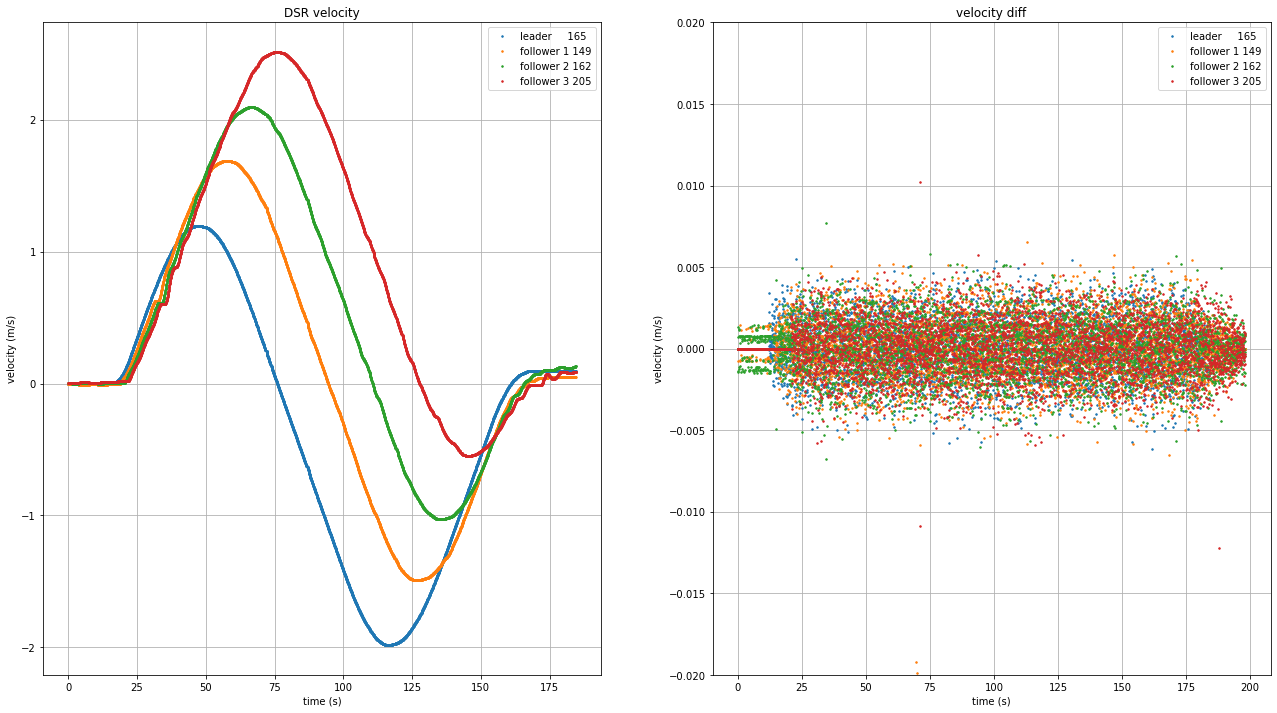

In [12]:
odom165_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot165/odom'))
# velx165_dsr = odom165_data_dsr['twist.twist.linear.x'].to_numpy() # plot this
velx165_dsr = odom165_data_dsr['pose.pose.position.x'].to_numpy() # plot this
odom165_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot165/odom'))
velx165_pds = odom165_data_pds['twist.twist.linear.x'].to_numpy() # plot this

odom149_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot149/odom'))
# velx149_dsr = odom149_data_dsr['twist.twist.linear.x'].to_numpy() # plot this
velx149_dsr = odom149_data_dsr['pose.pose.position.x'].to_numpy() # plot this
odom149_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot149/odom'))
velx149_pds = odom149_data_pds['twist.twist.linear.x'].to_numpy() # plot this

odom162_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot162/odom'))
# velx162_dsr = odom162_data_dsr['twist.twist.linear.x'].to_numpy() # plot this
velx162_dsr = odom162_data_dsr['pose.pose.position.x'].to_numpy() # plot this
odom162_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot162/odom'))
velx162_pds = odom162_data_pds['twist.twist.linear.x'].to_numpy() # plot this

odom205_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot205/odom'))
# velx205_dsr = odom205_data_dsr['twist.twist.linear.x'].to_numpy() # plot this
velx205_dsr = odom205_data_dsr['pose.pose.position.x'].to_numpy() # plot this
odom205_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot205/odom'))
velx205_pds = odom205_data_pds['twist.twist.linear.x'].to_numpy() # plot this

gain = 0.5

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(22,12))
ax1.plot(odom165_t_dsr, lowPass(velx165_dsr, lowPassGain=gain),'.', markersize=3, label='leader     165')
ax1.plot(odom149_t_dsr, lowPass(velx149_dsr, lowPassGain=gain),'.', markersize=3, label='follower 1 149')
ax1.plot(odom162_t_dsr, lowPass(velx162_dsr, lowPassGain=gain),'.', markersize=3, label='follower 2 162')
ax1.plot(odom205_t_dsr, lowPass(velx205_dsr, lowPassGain=gain),'.', markersize=3, label='follower 3 205')
ax1.set_xlabel('time (s)')
ax1.set_ylabel('velocity (m/s)')
ax1.set_title('DSR velocity')
# ax1.set_ylim(-0.15, 0.2)
# ax1.set_xlim(87.5, 90)
ax1.legend()
ax1.grid()

gain = 1.0

ax2.plot(odom165_t_pds[:-1], np.diff(velx165_pds),'.', markersize=3, label='leader     165')
ax2.plot(odom149_t_pds[:-1], np.diff(velx149_pds),'.', markersize=3, label='follower 1 149')
ax2.plot(odom162_t_pds[:-1], np.diff(velx162_pds),'.', markersize=3, label='follower 2 162')
ax2.plot(odom205_t_pds[:-1], np.diff(velx205_pds),'.', markersize=3, label='follower 3 205')
ax2.set_xlabel('time (s)')
ax2.set_ylabel('velocity (m/s)')
ax2.set_title('velocity diff')
ax2.set_ylim(-0.02, 0.02)
ax2.legend()
ax2.grid()

In [358]:
'''
1. lowpass velocity (gain 0.5)
2. if vel>0.15, vel=self.v
3. if np.abs(vel-vel_last)>
'''

'\n1. lowpass velocity (gain 0.5)\n2. if vel>0.15, vel=self.v\n3. if np.abs(vel-vel_last)>\n'

### Plot raw tag detection

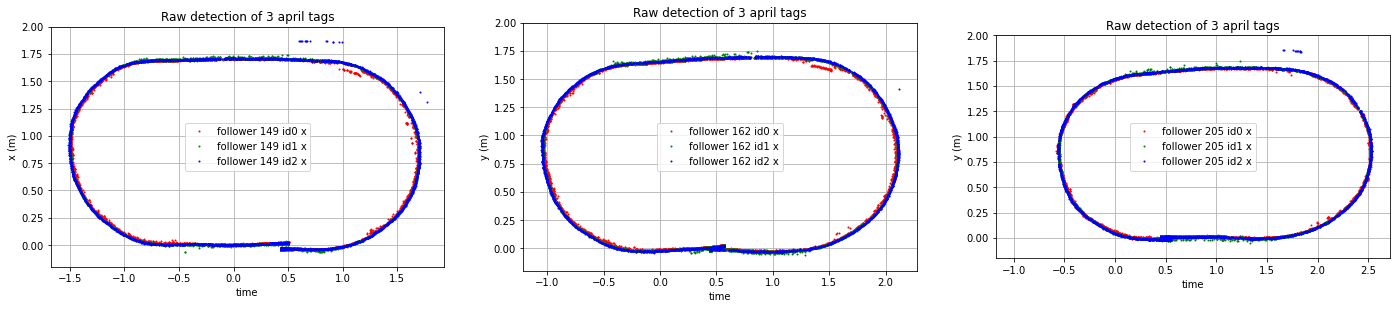

In [13]:
# raw data
tag149_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot149/tag_data'))
tag162_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot162/tag_data'))
tag205_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot205/tag_data'))
tag149_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot149/tag_data'))
tag162_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot162/tag_data'))
tag205_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot205/tag_data'))

fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(24,12))

ax1.plot(tag149_data_dsr.data_1, tag149_data_dsr.data_2,'r.', markersize=2,label='follower 149 id0 x')
ax1.plot(tag149_data_dsr.data_5, tag149_data_dsr.data_6,'g.', markersize=2,label='follower 149 id1 x')
ax1.plot(tag149_data_dsr.data_9, tag149_data_dsr.data_10,'b.', markersize=2,label='follower 149 id2 x')
ax1.set_xlabel('time')
ax1.set_ylabel('x (m)')
ax1.set_aspect('equal')
ax1.set_ylim(-0.2,2.0)
ax1.set_title('Raw detection of 3 april tags')
ax1.legend(loc='center')
ax1.grid()

ax2.plot(tag162_data_dsr.data_1, tag162_data_dsr.data_2,'r.', markersize=2,label='follower 162 id0 x')
ax2.plot(tag162_data_dsr.data_5, tag162_data_dsr.data_6,'g.', markersize=2,label='follower 162 id1 x')
ax2.plot(tag162_data_dsr.data_9, tag162_data_dsr.data_10,'b.', markersize=2,label='follower 162 id2 x')
ax2.set_xlabel('time')
ax2.set_ylabel('y (m)')
ax2.set_aspect('equal')
ax2.set_ylim(-0.2,2.0)
ax2.set_title('Raw detection of 3 april tags')
ax2.legend(loc='center')
ax2.grid()

ax3.plot(tag205_data_dsr.data_1, tag205_data_dsr.data_2,'r.', markersize=2,label='follower 205 id0 x')
ax3.plot(tag205_data_dsr.data_5, tag205_data_dsr.data_6,'g.', markersize=2,label='follower 205 id1 x')
ax3.plot(tag205_data_dsr.data_9, tag205_data_dsr.data_10,'b.', markersize=2,label='follower 205 id2 x')
ax3.set_xlabel('time')
ax3.set_ylabel('y (m)')
ax3.set_aspect('equal')
ax3.set_ylim(-0.2,2.0)
ax3.set_title('Raw detection of 3 april tags')
ax3.legend(loc='center')
ax3.grid()

### Plot tracking target

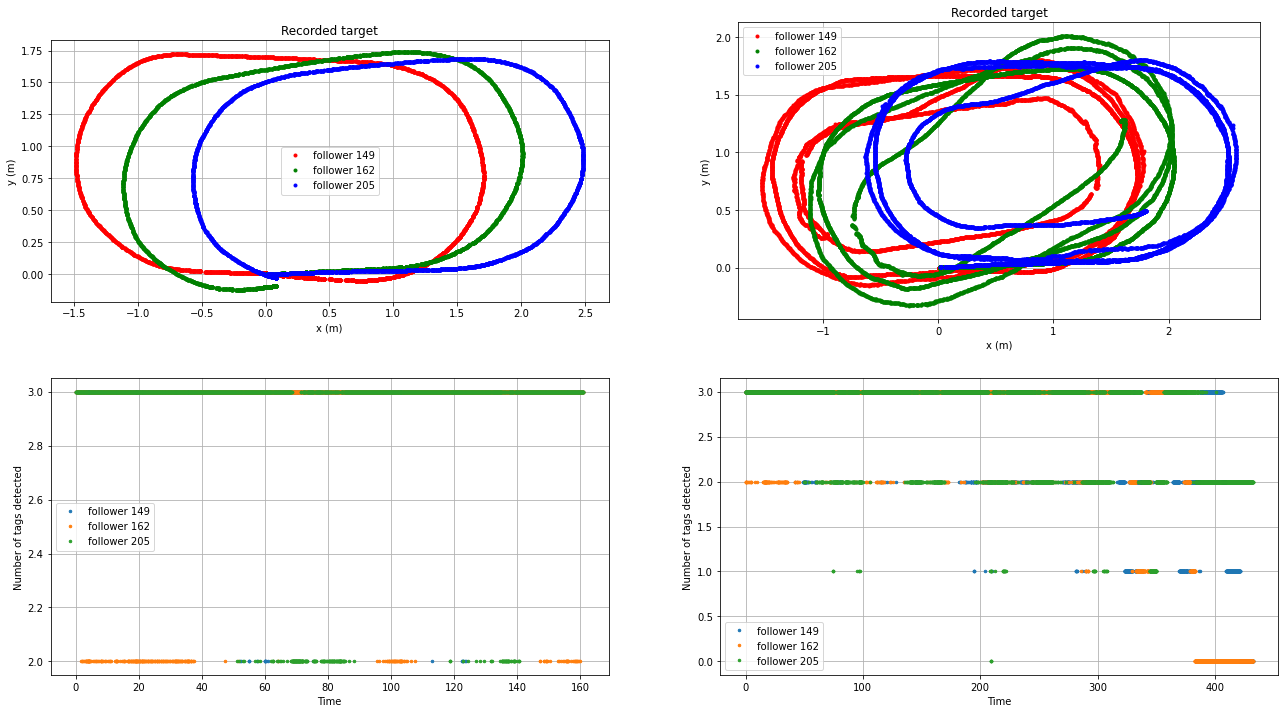

In [381]:
target149_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot149/target'))
target149_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot149/target'))
target162_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot162/target'))
target162_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot162/target'))
target205_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot205/target'))
target205_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot205/target'))

fig, ([ax1, ax2], [ax3, ax4]) = plt.subplots(2,2,figsize=(22,12))

ax1.plot(target149_data_dsr.x, target149_data_dsr.y,'r.', linewidth=3,label='follower 149')
ax1.plot(target162_data_dsr.x, target162_data_dsr.y,'g.', linewidth=3,label='follower 162')
ax1.plot(target205_data_dsr.x, target205_data_dsr.y,'b.', linewidth=3,label='follower 205')
ax1.set_xlabel('x (m)')
ax1.set_ylabel('y (m)')
ax1.set_aspect('equal')
ax1.set_title('Recorded target')
ax1.legend()
ax1.grid()

ax2.plot(target149_data_pds.x, target149_data_pds.y,'r.', linewidth=3,label='follower 149')
ax2.plot(target162_data_pds.x, target162_data_pds.y,'g.', linewidth=3,label='follower 162')
ax2.plot(target205_data_pds.x, target205_data_pds.y,'b.', linewidth=3,label='follower 205')
ax2.set_xlabel('x (m)')
ax2.set_ylabel('y (m)')
ax2.set_aspect('equal')
ax2.set_title('Recorded target')
ax2.legend()
ax2.grid()

time149_dsr = tag149_data_dsr.Time-tag149_data_dsr.Time[0]
time162_dsr = tag162_data_dsr.Time-tag162_data_dsr.Time[0]
time205_dsr = tag205_data_dsr.Time-tag205_data_dsr.Time[0]

time149_pds = tag149_data_pds.Time-tag149_data_pds.Time[0]
time162_pds = tag162_data_pds.Time-tag162_data_pds.Time[0]
time205_pds = tag205_data_pds.Time-tag205_data_pds.Time[0]

ax3.plot(time149_dsr, tag149_data_dsr.data_11,'.', markersize=5,label='follower 149')
ax3.plot(time162_dsr, tag162_data_dsr.data_11,'.', markersize=5,label='follower 162')
ax3.plot(time205_dsr, tag205_data_dsr.data_11,'.', markersize=5,label='follower 205')
ax3.set_xlabel('Time')
ax3.set_ylabel('Number of tags detected')
ax3.legend()
ax3.grid()

ax4.plot(time149_pds, tag149_data_pds.data_11,'.', markersize=5,label='follower 149')
ax4.plot(time162_pds, tag162_data_pds.data_11,'.', markersize=5,label='follower 162')
ax4.plot(time205_pds, tag205_data_pds.data_11,'.', markersize=5,label='follower 205')
ax4.set_xlabel('Time')
ax4.set_ylabel('Number of tags detected')
ax4.legend()
ax4.grid()

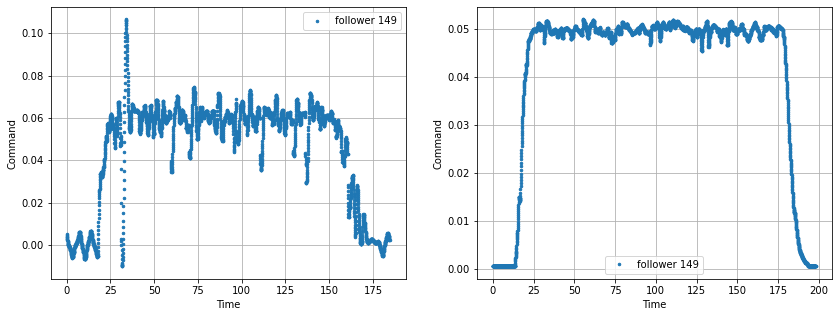

In [14]:
cmd_vel_149_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot149/cmd_vel'))
cmd_vel_162_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot162/cmd_vel'))
cmd_vel_205_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot205/cmd_vel'))

cmd_vel_time_149_dsr = cmd_vel_149_dsr.Time-cmd_vel_149_dsr.Time[0]
cmd_vel_time_162_dsr = cmd_vel_162_dsr.Time-cmd_vel_162_dsr.Time[0]
cmd_vel_time_205_dsr = cmd_vel_205_dsr.Time-cmd_vel_205_dsr.Time[0]

cmd_vel_149_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot149/cmd_vel'))
cmd_vel_162_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot162/cmd_vel'))
cmd_vel_205_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot205/cmd_vel'))

cmd_vel_time_149_pds = cmd_vel_149_pds.Time-cmd_vel_149_pds.Time[0]
cmd_vel_time_162_pds = cmd_vel_162_pds.Time-cmd_vel_162_pds.Time[0]
cmd_vel_time_205_pds = cmd_vel_205_pds.Time-cmd_vel_205_pds.Time[0]

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,5))
ax1.plot(cmd_vel_time_149_dsr, cmd_vel_149_dsr['linear.x'],'.', markersize=5,label='follower 149')
# ax1.plot(cmd_vel_time_162_dsr, cmd_vel_162_dsr['linear.x'],'-', markersize=5,label='follower 162')
# ax1.plot(cmd_vel_time_205_dsr, cmd_vel_205_dsr['linear.x'],'-', markersize=5,label='follower 205')
ax1.set_xlabel('Time')
ax1.set_ylabel('Command')
ax1.legend()
ax1.grid()

ax2.plot(cmd_vel_time_149_pds, cmd_vel_149_pds['linear.x'],'.', markersize=5,label='follower 149')
# ax2.plot(cmd_vel_time_162_pds, cmd_vel_162_pds['linear.x'],'-', markersize=5,label='follower 162')
# ax2.plot(cmd_vel_time_205_pds, cmd_vel_205_pds['linear.x'],'-', markersize=5,label='follower 205')
ax2.set_xlabel('Time')
ax2.set_ylabel('Command')
ax2.legend()
ax2.grid()

### Plot relative angle

In [15]:
def zoh(input_time, input_array, total_time=250, dt=0.025):
    
    steps = int(total_time/dt)
    output_array = np.zeros(steps)
    output_time  = np.linspace(0, total_time, steps)

    for i in range(len(output_time)):
        idx = np.searchsorted(input_time, output_time[i], side='left')
        if idx > 0 and idx == len(input_array):
            output_array[i] = input_array[idx-1]
        else:
            output_array[i] = input_array[idx]

    return output_time, output_array

def toDegree(rad):

    return rad*180/np.pi

def filter180(array, threshold=180):

    # get all indices that has values larger than 180
    indx_l_180 = np.nonzero(array<-180)
    indx_g_180 = np.nonzero(array>180)
    # asign previous index's value to these indices
    array[np.array(indx_l_180)] += 360
    array[np.array(indx_g_180)] -= 360

    return array

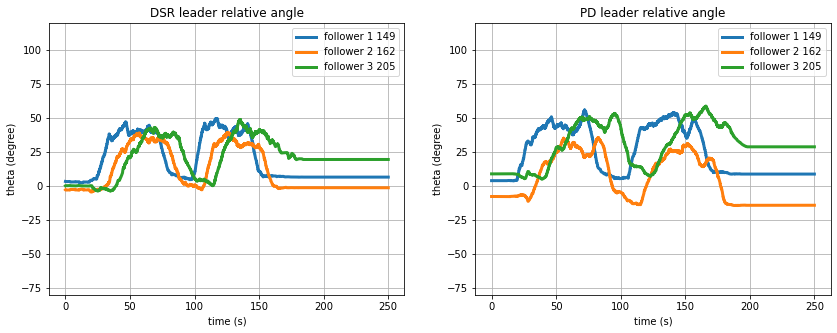

In [16]:
from scipy.spatial.transform import Rotation as R

r = R.from_quat(np.array([odom165_data_dsr['pose.pose.orientation.x'].to_numpy(),
                          odom165_data_dsr['pose.pose.orientation.y'].to_numpy(), 
                          odom165_data_dsr['pose.pose.orientation.z'].to_numpy(),
                          odom165_data_dsr['pose.pose.orientation.w'].to_numpy()]).T)
head165_dsr = r.as_euler('zyx', degrees=True)[:,0]
odom165_t_dsr_zoh, head165_dsr_zoh = zoh(odom165_t_dsr, head165_dsr) # plot this
r = R.from_quat(np.array([odom165_data_pds['pose.pose.orientation.x'].to_numpy(),
                          odom165_data_pds['pose.pose.orientation.y'].to_numpy(), 
                          odom165_data_pds['pose.pose.orientation.z'].to_numpy(),
                          odom165_data_pds['pose.pose.orientation.w'].to_numpy()]).T)
head165_pds = r.as_euler('zyx', degrees=True)[:,0]
odom165_t_pds_zoh, head165_pds_zoh = zoh(odom165_t_pds, head165_pds) # plot this

r = R.from_quat(np.array([odom149_data_dsr['pose.pose.orientation.x'].to_numpy(),
                          odom149_data_dsr['pose.pose.orientation.y'].to_numpy(), 
                          odom149_data_dsr['pose.pose.orientation.z'].to_numpy(),
                          odom149_data_dsr['pose.pose.orientation.w'].to_numpy()]).T)
head149_dsr = r.as_euler('zyx', degrees=True)[:,0]
odom149_t_dsr_zoh, head149_dsr_zoh = zoh(odom149_t_dsr, head149_dsr) # plot this
r = R.from_quat(np.array([odom149_data_pds['pose.pose.orientation.x'].to_numpy(),
                          odom149_data_pds['pose.pose.orientation.y'].to_numpy(), 
                          odom149_data_pds['pose.pose.orientation.z'].to_numpy(),
                          odom149_data_pds['pose.pose.orientation.w'].to_numpy()]).T)
head149_pds = r.as_euler('zyx', degrees=True)[:,0]
odom149_t_pds_zoh, head149_pds_zoh = zoh(odom149_t_pds, head149_pds) # plot this

r = R.from_quat(np.array([odom162_data_dsr['pose.pose.orientation.x'].to_numpy(),
                          odom162_data_dsr['pose.pose.orientation.y'].to_numpy(), 
                          odom162_data_dsr['pose.pose.orientation.z'].to_numpy(),
                          odom162_data_dsr['pose.pose.orientation.w'].to_numpy()]).T)
head162_dsr = r.as_euler('zyx', degrees=True)[:,0]
odom162_t_dsr_zoh, head162_dsr_zoh = zoh(odom162_t_dsr, head162_dsr) # plot this
r = R.from_quat(np.array([odom162_data_pds['pose.pose.orientation.x'].to_numpy(),
                          odom162_data_pds['pose.pose.orientation.y'].to_numpy(), 
                          odom162_data_pds['pose.pose.orientation.z'].to_numpy(),
                          odom162_data_pds['pose.pose.orientation.w'].to_numpy()]).T)
head162_pds = r.as_euler('zyx', degrees=True)[:,0]
odom162_t_pds_zoh, head162_pds_zoh = zoh(odom162_t_pds, head162_pds) # plot this

r = R.from_quat(np.array([odom205_data_dsr['pose.pose.orientation.x'].to_numpy(),
                          odom205_data_dsr['pose.pose.orientation.y'].to_numpy(), 
                          odom205_data_dsr['pose.pose.orientation.z'].to_numpy(),
                          odom205_data_dsr['pose.pose.orientation.w'].to_numpy()]).T)
head205_dsr = r.as_euler('zyx', degrees=True)[:,0]
odom205_t_dsr_zoh, head205_dsr_zoh = zoh(odom205_t_dsr, head205_dsr) # plot this
r = R.from_quat(np.array([odom205_data_pds['pose.pose.orientation.x'].to_numpy(),
                          odom205_data_pds['pose.pose.orientation.y'].to_numpy(), 
                          odom205_data_pds['pose.pose.orientation.z'].to_numpy(),
                          odom205_data_pds['pose.pose.orientation.w'].to_numpy()]).T)
head205_pds = r.as_euler('zyx', degrees=True)[:,0]
odom205_t_pds_zoh, head205_pds_zoh = zoh(odom205_t_pds, head205_pds) # plot this

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,5))
ax1.plot(odom149_t_dsr_zoh, filter180(head165_dsr_zoh-head149_dsr_zoh), '-', linewidth=3, label='follower 1 149')
ax1.plot(odom162_t_dsr_zoh, filter180(head149_dsr_zoh-head162_dsr_zoh), '-', linewidth=3, label='follower 2 162')
ax1.plot(odom205_t_dsr_zoh, filter180(head162_dsr_zoh-head205_dsr_zoh), '-', linewidth=3, label='follower 3 205')
ax1.set_title('DSR leader relative angle')
ax1.set_xlabel('time (s)')
ax1.set_ylabel('theta (degree)')
ax1.set_ylim(-80, 120)
ax1.legend()
ax1.grid()

ax2.plot(odom149_t_pds_zoh, filter180(head165_pds_zoh-head149_pds_zoh), '-', linewidth=3, label='follower 1 149')
ax2.plot(odom162_t_pds_zoh, filter180(head149_pds_zoh-head162_pds_zoh), '-', linewidth=3, label='follower 2 162')
ax2.plot(odom205_t_pds_zoh, filter180(head162_pds_zoh-head205_pds_zoh), '-', linewidth=3, label='follower 3 205')
ax2.set_title('PD leader relative angle')
ax2.set_xlabel('time (s)')
ax2.set_ylabel('theta (degree)')
ax2.set_ylim(-80, 120)
ax2.legend()
ax2.grid()

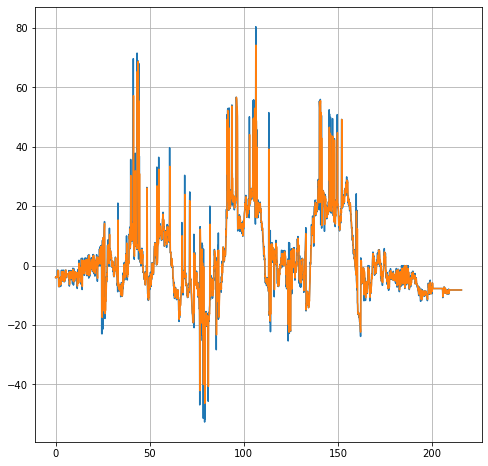

In [401]:
# sensing149_data = pd.read_csv(readbag_dsr.message_by_topic('/tbot149/april_data_multi'), on_bad_lines='skip')
# sensing149_freq = readbag_dsr.topic_table['Frequency'][0]
# leader_phi_149  = sensing149_data['data_4'].to_numpy()


# sensing205_data = pd.read_csv(readbag_dsr.message_by_topic('/tbot205/april_data_multi'), on_bad_lines='skip')
# sensing205_freq = readbag_dsr.topic_table['Frequency'][11]
# leader_phi_205  = sensing205_data['data_4'].to_numpy()


# sensing162_data = pd.read_csv(readbag_dsr.message_by_topic('/tbot162/april_data_multi'), on_bad_lines='skip')
# sensing162_freq = readbag_dsr.topic_table['Frequency'][5]
# leader_phi_162  = sensing162_data['data_4'].to_numpy()

# def lowPass(u, y_last, lowPassGain=0.2):

#     return lowPassGain*u + (1-lowPassGain)*y_last 

# leader_phi_149_lowpass = np.zeros(len(leader_phi_149))
# leader_phi_149_last = leader_phi_149[0]
# for i in range(len(leader_phi_149)):

#     leader_phi_149_lowpass[i] = lowPass(leader_phi_149[i], leader_phi_149_last, lowPassGain=0.2)
#     leader_phi_149_last = leader_phi_149[i]

# plt.figure(figsize=(8,8))
# plt.plot(np.arange(len(leader_phi_149))/sensing149_freq, leader_phi_149*180/np.pi)
# plt.plot(np.arange(len(leader_phi_149))/sensing149_freq, leader_phi_149_lowpass*180/np.pi)
# # plt.plot(np.arange(len(leader_phi_205))/sensing205_freq, leader_phi_205*180/np.pi)
# # plt.plot(np.arange(len(leader_phi_162))/sensing162_freq, leader_phi_162*180/np.pi)
# plt.grid()